In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
from scipy.integrate import solve_ivp

In [2]:
# Model parameters
N = 100000 # Total population in 2010
mu = 0#1/(70*365);  # Natural mortality rate per day
pi = 0#mu*N  # Birth rate per day
beta_0 = 0.0007 # Transmission rate
eps = 0.024 # 6 weeks #0.2     # Progression from E to I- 5 days
eta_0 = 1/15 #0.33 #0.0071  # baseline care seeking delay, 3 days
p = 0.8     # Proportion seeking L
k_l = 1/2  # The base screening delay at L, 2 days
k_h = 1  # The base diagnosis delay at H, 2 hours= 1/12 days
gamma_l = 0.6 #0.7      # Sensitivity of smear microscopy
q_h = 0.8      # Sensitivity of GeneXpert
alpha = 0.005  # Treatment recovery rate 1/180 
sigma = 0#1/(0.5*365) #0.03  # Immunity loss, after 18 months
phi = 1/30 #0.1   # Re-entry from F to I, assumed 1 month
phi2 = 1/90
mu_TB = 0.01 # # TB-specific mortality rate-> assumed
lamda = 0.9
xi = 0.7
max_T = 1
surges = 1
omega0 = 1
# C_L = 100  # Capacity of L (tests/day) for two Smear microscopy
# C_H = 16 #500   # Capacity of H (tests/day)
D_max = 15   # Maximum delay (days)
Diagnosis_D_max = 7 # maximum diagnosis delay, assumed 1 days
Screening_D_max = 7 # maximum screening delay, assumed 2 days

d1 = d2 = d3 = d4 = 0.001


# Initial conditions
I0 = 10   # Initial infected cases
S0 = N - I0
E0 = 0
L0 = 0
H0 = 0
T0 = 0
F0 = 0
R0 = 0
D0 = 0
New_cases0 = 0
New_treated = 0
state0 = [S0, E0, I0, L0, H0, T0, F0, R0, New_cases0, New_treated, D0]

# Time vector
t = np.linspace(0, max_T*365, max_T*365)  # 1 year

In [3]:
demand_amplitude = 1
def initial_delay_function(C, Q, D_max, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max / (1 + np.exp(x))

def diagnosis_delay_function(C, Q, D_max_d, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max_d / (1 + np.exp(x))

# Effective rate with delay
def effective_rate(base_rate, D):
    return base_rate / (1 + base_rate * D)

def beta_t(t, beta0, surges=1, demand_amplitude = 1):
    
    return beta0 * (1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/3))   

# TB model ODEs
def tb_model( t, state, params):
    
    S, E, I, L, H, T, F, R, New_cases, New_treated, D  = state
    
    NN = S + E + I + H + L + F + T + R + D
    
    
    
    eps, eta_0, p, gamma_l, k_h, k_l,  q_h, alpha, phi, mu_TB, C_L, C_H, omega0, D_max, Diagnosis_D_max, Screening_D_max, beta_0, lamda, xi, demand_amplitude, surges, d1, d2, d3 = params

    beta  = beta_0 #beta_t(t,  beta_0)

    FOI = beta*(I + xi*(H + L) + F + D)/(1+ lamda*(I + xi*(H + L) + F + D))

    omega = omega0* (p*eta_0 * I/NN) * (S+E+R)
    
    # Demands
    Q_L = p*eta_0 * I + omega #*(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    Q_H = (1 - p) * eta_0* I  + gamma_l *k_l* L #(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    
    # Initial care seeking Delays
    D_L_initial = initial_delay_function(C_L, Q_L, D_max)
    D_H_initial = initial_delay_function(C_H, Q_H, D_max)

    #Screening/Diagnosis delay
    D_L_screeing = diagnosis_delay_function(C_L, Q_L, Screening_D_max)
    D_H_daignosis = diagnosis_delay_function(C_H, Q_H, Diagnosis_D_max)

    # initial patiend care-seeking delay rate
    eta_L = effective_rate(eta_0, D_L_initial)
    eta_H = effective_rate(eta_0, D_H_initial)
   

    #Screening/Diagnosis delay rate
    k_L = effective_rate(k_l, D_L_screeing)
    k_H =  effective_rate(k_h, D_H_daignosis)

    new_L = p * eta_L
    new_H = (1 - p) * eta_H 

    #L_to_H = k_L* (1 + demand_amplitude * np.sin(2 * np.pi * 3 * t/365 - np.pi/2))
    
    # ODEs
    dSdt = -FOI* S  
    dEdt = FOI * S  - eps* E
    dIdt = eps * E - (new_L + new_H ) * I + (1-d1)*phi * F + phi2*D - mu_TB * I 
    dLdt = new_L * I - (1-d2)*k_L * L -  mu_TB* L - d2*L
    dHdt = new_H * I + (1-d2)*k_L*gamma_l * L - (1-d3)*k_H * H - mu_TB * H - d3*H
    dTdt = (1-d3)*q_h * k_H * H - alpha * T
    dFdt = (1-d2)*(1 - gamma_l) * k_L * L + (1-d3)*(1 - q_h) * k_H * H - ((1-d1)*phi + mu_TB + d1) * F 
    dRdt = alpha * T 
    dNewCases = FOI * S 
    dNewTreated = (1-d3)*q_h * k_H * H
    dDdt = d1*F + d2*L + d3* H - (phi2 + mu_TB)*D
    
    return [dSdt, dEdt, dIdt, dLdt, dHdt, dTdt, dFdt, dRdt, dNewCases, dNewTreated, dDdt]

In [4]:
base_eta_0 = eta_0; base_k_h = k_h; base_q_h = q_h; base_k_l = k_l; base_gamma_l = gamma_l
imp_eta_0 = 1/7; imp_k_h = 4; imp_q_h = 0.9; imp_k_l = 1; imp_gamma_l = 0.8
#imp_eta_0 = 1/7; imp_k_l = 5/8; imp_gamma_l = 0.72; imp_k_h = 5/4; imp_q_h = 0.96; 

# Define scenarios

Only_L_OR_H_scenarios = ["Scenario 1", "Scenario 2", "Scenario 3",  "Improve all in L", "Scenario 5", "Scenario 6",  "Improve all in H"]

scenarios_discription = ["Improve base patient delay", "Improve screening sensitivity", "Improve base screening delay", "Improve all in L", "Improve diagnosis sensitivity", "Improve base diagnosis delay", "Improve all in H"]

summary_results = {}
##### kk=1-no capacity constraint, kk=2- moderate capacity constraint, kk=3-high capacity constraint
for kk in [0,1,2]:

    if kk == 0:
        C_H = 64
        C_L = 300
        
    elif kk == 1:
        C_H = 32
        C_L = 200
        
    elif kk == 2:
        C_H = 16
        C_L = 100
    #Base_CI =  base_sol.y[9][-1] #np.sum(base_sol.y[2])

    
    improvements = {
        "Baseline": {"eta_0": eta_0, "C_H": C_H, "k_h": k_h, "q_h": q_h, "C_L": C_L, "k_l": k_l, "gamma_l": gamma_l},
    
        # Improve patient delay
        "Scenario 1": {"eta_0": imp_eta_0,"C_H": C_H,  "k_h": base_k_h, "q_h": base_q_h, "C_L": C_L, "k_l": imp_k_l, "gamma_l": base_gamma_l},
        #improvment in L
        "Scenario 2": {"eta_0": base_eta_0,"C_H": C_H,  "k_h": base_k_h, "q_h": base_q_h, "C_L": C_L, "k_l": imp_k_l, "gamma_l": base_gamma_l},
        "Scenario 3" : {"eta_0": base_eta_0,"C_H": C_H, "k_h": base_k_h, "q_h": base_q_h, "C_L": C_L, "k_l": base_k_l, "gamma_l": imp_gamma_l},
        #"Scenario 4": {"eta_0": base_eta_0, "C_H": base_C_H, "k_h": base_k_h, "q_h": base_q_h, "C_L": imp_C_L, "k_l": base_k_l, "gamma_l": base_gamma_l},
        "Improve all in L" : {"eta_0": base_eta_0,"C_H": C_H, "k_h": base_k_h, "q_h": base_q_h, "C_L": C_L, "k_l": imp_k_l, "gamma_l": imp_gamma_l},
        
        
        #improvment in H
        "Scenario 5": {"eta_0": base_eta_0,"C_H":  C_H, "k_h": imp_k_h, "q_h":base_q_h, "C_L":  C_L, "k_l":base_k_l, "gamma_l": base_gamma_l},
        "Scenario 6" : {"eta_0": base_eta_0, "C_H":  C_H, "k_h": base_k_h, "q_h": imp_q_h, "C_L":  C_L, "k_l": base_k_l, "gamma_l": base_gamma_l},
        #"Scenario 7": {"eta_0": base_eta_0,"C_H": C_H, "k_h": base_k_h, "q_h": base_q_h, "C_L":  C_L, "k_l": base_k_l, "gamma_l": base_gamma_l}, 
        "Improve all in H" : {"eta_0": base_eta_0,"C_H": C_H, "k_h": imp_k_h, "q_h": imp_q_h, "C_L":  C_L, "k_l": base_k_l, "gamma_l": base_gamma_l},
        
         #improve all
        "Improve All": {"eta_0": imp_eta_0, "C_H": C_H, "k_h": imp_k_h, "q_h": imp_q_h, "C_L": C_L, "k_l": imp_k_l, "gamma_l": imp_gamma_l},
          
    }

    summary_results[kk] = []
    #summary_solutions[kk] = {}

    # compute baseline first
    baseline_params = improvements["Baseline"]
    base_param_tuple = (eps, baseline_params['eta_0'], p, baseline_params['gamma_l'], baseline_params['k_h'], baseline_params['k_l'], baseline_params['q_h'], alpha, phi, mu_TB, baseline_params['C_L'], baseline_params['C_H'], omega0, D_max, 
                       Diagnosis_D_max, Screening_D_max,  beta_0, lamda, xi, demand_amplitude, surges, d1, d2, d3)
    baseline_sol = solve_ivp(
            tb_model,
            [t[0], t[-1]],
            state0,
            method = 'LSODA',
            t_eval = t,
            args = (base_param_tuple, ),
            max_step = 0.5,
            rtol = 1e-6, atol = 1e-8
        ) 
    Base_CI = baseline_sol.y[9][-1]
       
    for scenario_name, param_dict in improvements.items():
        
        param_tuple = (eps, param_dict['eta_0'], p, param_dict['gamma_l'], param_dict['k_h'], param_dict['k_l'], param_dict['q_h'], alpha, phi, mu_TB, param_dict['C_L'], param_dict['C_H'], omega0, D_max, 
                       Diagnosis_D_max, Screening_D_max,  beta_0, lamda, xi, demand_amplitude, surges, d1, d2, d3
            )
    
        sol = solve_ivp(
            tb_model,
            [t[0], t[-1]],
            state0,
            method = 'LSODA',
            t_eval = t,
            args = (param_tuple, ),
            max_step = 0.5,
            rtol = 1e-6, atol = 1e-8
        ) 
        
            
        label = f"{scenario_name}"
        
     
        cum_cases =  sol.y[9][-1] # np.sum(base_sol.y[2])
            
        Change_in_cum_treated = ((cum_cases-Base_CI)/Base_CI)*100   
        
        summary_results[kk].append({
            "Scenario": scenario_name,
            "change_in_CT": Change_in_cum_treated
        })
        
        #summary_solutions [label] = ((cum_cases-Base_CI)/Base_CI)*100

    

In [5]:
summary_df = pd.DataFrame(summary_results)
#summary_df.sort_values(by=["Capacity_scenario"], inplace=True)

In [6]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(summary_df[2])


0        {'Scenario': 'Baseline', 'change_in_CT': 0.0}
1    {'Scenario': 'Scenario 1', 'change_in_CT': 11....
2    {'Scenario': 'Scenario 2', 'change_in_CT': 1.1...
3    {'Scenario': 'Scenario 3', 'change_in_CT': 15....
4    {'Scenario': 'Improve all in L', 'change_in_CT...
5    {'Scenario': 'Scenario 5', 'change_in_CT': 1.0...
6    {'Scenario': 'Scenario 6', 'change_in_CT': 8.8...
7    {'Scenario': 'Improve all in H', 'change_in_CT...
8    {'Scenario': 'Improve All', 'change_in_CT': 38...
Name: 2, dtype: object

In [7]:
list(summary_df[2])

[{'Scenario': 'Baseline', 'change_in_CT': np.float64(0.0)},
 {'Scenario': 'Scenario 1', 'change_in_CT': np.float64(11.322786130561958)},
 {'Scenario': 'Scenario 2', 'change_in_CT': np.float64(1.1773493429296618)},
 {'Scenario': 'Scenario 3', 'change_in_CT': np.float64(15.013479957481454)},
 {'Scenario': 'Improve all in L',
  'change_in_CT': np.float64(16.328605408242403)},
 {'Scenario': 'Scenario 5', 'change_in_CT': np.float64(1.03670381909721)},
 {'Scenario': 'Scenario 6', 'change_in_CT': np.float64(8.887147878941757)},
 {'Scenario': 'Improve all in H',
  'change_in_CT': np.float64(9.973819615478902)},
 {'Scenario': 'Improve All', 'change_in_CT': np.float64(38.1100890190546)}]

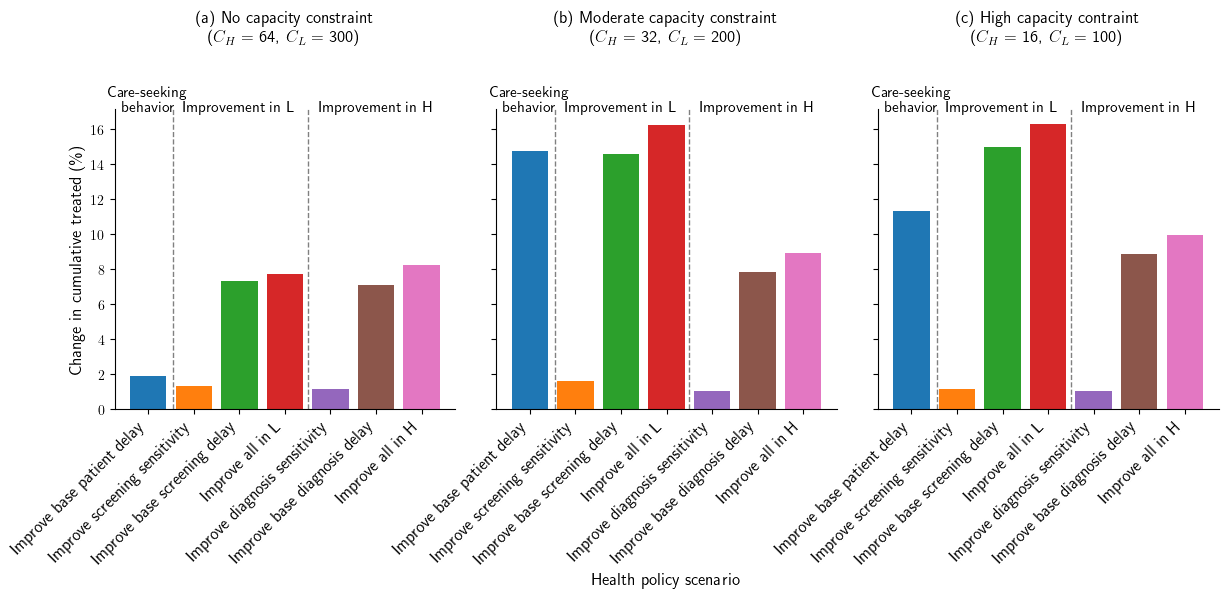

In [8]:
scenarios_discription = ["Improve base patient delay", "Improve screening sensitivity", "Improve base screening delay",  "Improve all in L", "Improve diagnosis sensitivity", "Improve base diagnosis delay",  "Improve all in H"]
scenario_colors = {
    "Scenario 1": "tab:blue",
    "Scenario 2": "tab:orange",
    "Scenario 3": "tab:green",
    "Improve all in L": "tab:red",
    "Scenario 5": "tab:purple",
    "Scenario 6": "tab:brown",
    "Improve all in H": "tab:pink"
}
capacity_scenarios = {0: {'C_H': 64, 'C_L': 300},
                      1: {'C_H': 32, 'C_L': 200},
                      2: {'C_H': 16, 'C_L': 100},
   }

panel_labels = {0: "(a) No capacity constraint", 1: "(b) Moderate capacity constraint", 2: "(c) High capacity contraint"}

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.28,
    top=0.88,
    wspace=0.12
) 

# changes1 = [item["change_in_CT"] for item in summary_results[1]]
# max_bar = max(changes1)
text_height = 17   # 8% above tallest bar

for idx, kk in enumerate([0, 1, 2]):
    
    excluded = ["Baseline", "Improve All"]

    filtered_results = [
        item for item in summary_results[kk]
        if item["Scenario"] not in excluded
    ]
    
    scenarios = [item["Scenario"] for item in filtered_results]
    changes = [item["change_in_CT"] for item in filtered_results]
    colors = [scenario_colors[s] for s in scenarios]
    
    ax = axes[idx]
    ax.bar(scenarios, changes, color= colors)
    x_pos1 = np.arange(len(scenarios_discription))
    ax.set_xticks(x_pos1, scenarios_discription, rotation=45, ha="right",
           fontsize=12, fontweight='bold')
    ax.set_title(f"{panel_labels[kk]} \n ($C_H$ = {capacity_scenarios[kk]['C_H']}, $C_L$ = {capacity_scenarios[kk]['C_L']})", y=1.2, fontsize=12, fontweight='bold')
    if kk == 1:
        
        ax.set_xlabel("Health policy scenario", fontsize=12, fontweight='bold')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=1)
    ax.axvline(x=0.55, color='gray', linestyle='--', linewidth=1)
    # Add 'in L' and 'in H' labels
    
    # ---- Dynamic text height based on tallest bar ----
    

    ax.text(0, text_height, 'Care-seeking\nbehavior',
            ha='center', fontsize=11, fontweight='bold')

    ax.text(2, text_height, 'Improvement in L',
            ha='center', fontsize=11, fontweight='bold')

    ax.text(5, text_height, 'Improvement in H',
            ha='center', fontsize=11, fontweight='bold')
    
    if idx == 0:
        ax.set_ylabel("Change in cumulative treated (\\%)", fontsize=12, fontweight='bold')

#plt.tight_layout()
plt.show()


In [9]:
# Convert to DataFrame
# summary_df = pd.DataFrame(summary_results)
#summary_df.to_excel('Scenario_assesment_result.xlsx', index=False)
#summary_df.sort_values(by=["Scenario"], inplace=True)
# filtered_df = summary_df[summary_df["Scenario"].isin(Only_L_OR_H_scenarios)]
# display(filtered_df)

In [11]:
capacity_scenarios[0]['C_H']

64